# Análisis de Absentismo Laboral - RHHH

### Preguntas de negocio

> ¿Qué variables personales y laborales están más asociadas a niveles elevados de absentismo?  

> Cómo ajustamos nuestras políticas internas para abordar proactivamente estos perfiles de riesgo y reducir las ausencias?



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import numpy as np

import os
from dotenv import load_dotenv

## Carga de datos

In [2]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv()
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_07072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-06.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados desde el archivo CSV correctamente.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos cargados desde el archivo CSV correctamente.'

### Utilizamos una REGRESION BINOMIAL NEGATIVA 

In [3]:
# ==============================
# 1. Base para el modelo
# ==============================

df_modelo = (
    df.groupby("ID_Employee")
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
        Age=("Age", "first"),
        Education=("Education", "first"),
        Son=("Son", "first"),
        Social_Drinker=("Social_Drinker", "first"),
        Social_Smoker=("Social_Smoker", "first"),
        Pet=("Pet", "first"),
        Body_Mass_Index=("Body_Mass_Index", "first"),
        Transportation_Expense=("Transportation_Expense", "mean"),
        Distance_Residence_Work=("Distance_Residence_Work", "first"),
        Service_Time=("Service_Time", "first"),
        Work_load_Average_Day=("Work_load_Average_Day", "mean"),
        Hit_Target=("Hit_Target", "mean"),
        Disciplinary_Failure=("Disciplinary_Failure", "max")
    )
    .reset_index()
)

# ==============================
# 2. Modelo Binomial Negativo
# ==============================

formula = """
Total_Horas_Absentismo ~
Age +
C(Education) +
Son +
C(Social_Drinker) +
C(Social_Smoker) +
Pet +
Body_Mass_Index +
Transportation_Expense +
Distance_Residence_Work +
Service_Time +
Work_load_Average_Day +
Hit_Target +
C(Disciplinary_Failure)
"""

modelo_nb = smf.negativebinomial(
    formula=formula,
    data=df_modelo
).fit(disp=False, maxiter=1000)

print(modelo_nb.summary())

                       NegativeBinomial Regression Results                        
Dep. Variable:     Total_Horas_Absentismo   No. Observations:                  136
Model:                   NegativeBinomial   Df Residuals:                      120
Method:                               MLE   Df Model:                           15
Date:                    Wed, 08 Jul 2026   Pseudo R-squ.:                 0.03780
Time:                            16:19:20   Log-Likelihood:                -563.40
converged:                           True   LL-Null:                       -585.53
Covariance Type:                nonrobust   LLR p-value:                 0.0001000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        8.9543      8.771      1.021      0.307      -8.236      26.145
C(Education)[T.2]                0.0887      

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


- ### Segmentamos por infulencia 


In [4]:

# Resultados del modelo
resultados = pd.DataFrame({
    "Variable": modelo_nb.params.index,
    "Coeficiente": modelo_nb.params.values,
    "P_Value": modelo_nb.pvalues.values
})

# Quitamos intercepto y alpha
resultados = resultados[
    ~resultados["Variable"].isin(["Intercept", "alpha"])
].copy()

# Convertimos coeficientes a efecto porcentual
resultados["IRR"] = np.exp(resultados["Coeficiente"])
resultados["Efecto_%"] = (resultados["IRR"] - 1) * 100
resultados["Impacto_Abs"] = resultados["Efecto_%"].abs()

# Limpiar nombres
resultados["Variable_Limpia"] = (
    resultados["Variable"]
    .str.replace("C(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("[T.", " = ", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Etiqueta de significancia
resultados["Significancia"] = resultados["P_Value"].apply(
    lambda p: "Significativa" if p < 0.05 else "No significativa"
)

# Etiqueta p-value
resultados["P_Label"] = resultados["P_Value"].apply(
    lambda p: "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
)

- Variables mas influyentes

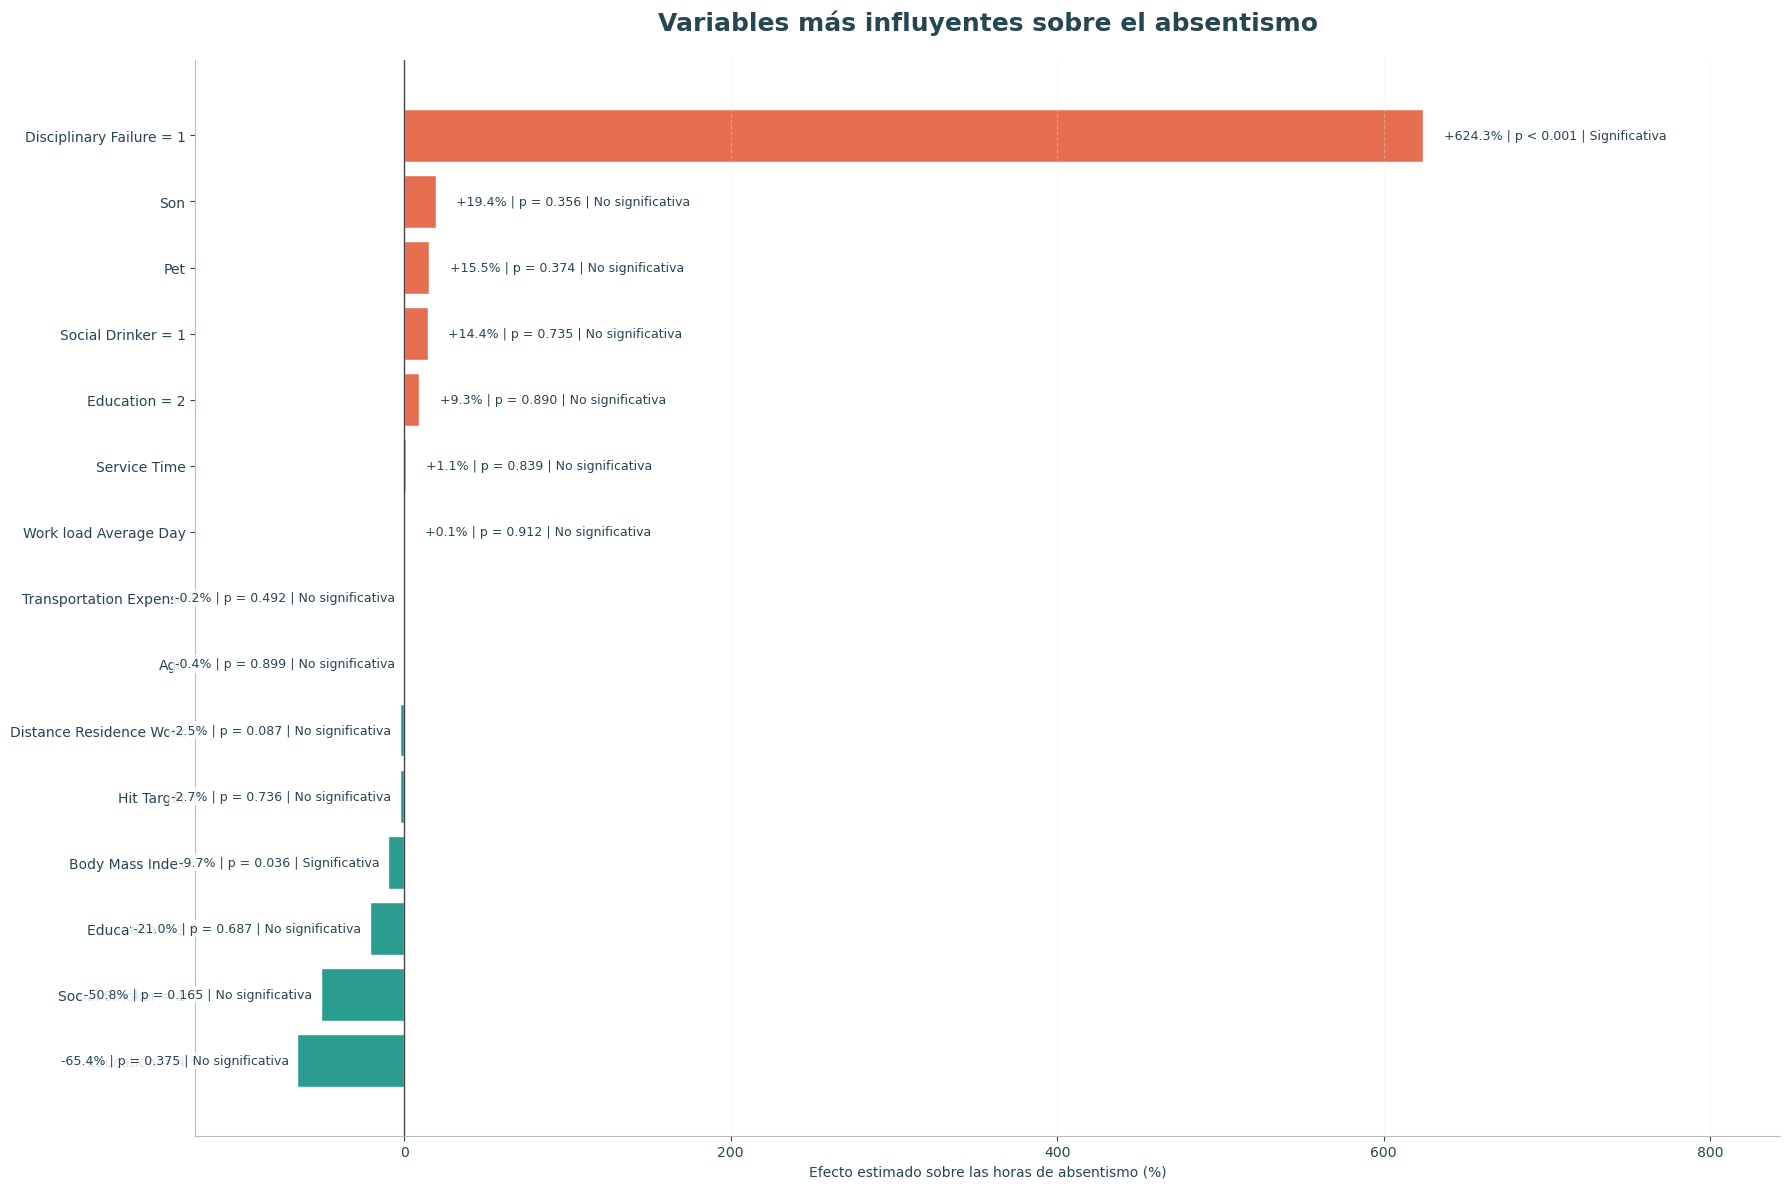

In [5]:
# ==============================
# Variables más influyentes
# ==============================

mas_influyentes = (
    resultados
    .sort_values("Impacto_Abs", ascending=False)
    .copy()
)

mas_influyentes = mas_influyentes.sort_values("Efecto_%")

color_aumenta = "#E76F51"
color_reduce = "#2A9D8F"
color_texto = "#264653"
color_grid = "#E5E4E4"

colores = [
    color_aumenta if efecto > 0 else color_reduce
    for efecto in mas_influyentes["Efecto_%"]
]

fig, ax = plt.subplots(figsize=(18, 12))

bars = ax.barh(
    mas_influyentes["Variable_Limpia"],
    mas_influyentes["Efecto_%"],
    color=colores,
    edgecolor="white",
    linewidth=1
)

ax.axvline(0, color="#444444", linewidth=1)

ax.set_title(
    "Variables más influyentes sobre el absentismo",
    fontsize=18,
    fontweight="bold",
    color=color_texto,
    pad=22
)

ax.set_xlabel("Efecto estimado sobre las horas de absentismo (%)", color=color_texto)
ax.grid(axis="x", linestyle="--", alpha=0.35, color=color_grid)

# Límites con espacio extra para etiquetas
min_x = mas_influyentes["Efecto_%"].min()
max_x = mas_influyentes["Efecto_%"].max()

ax.set_xlim(min_x - abs(min_x) * 0.65 - 20, max_x * 1.35)

# Etiquetas
for bar, efecto, p_label, sig in zip(
    bars,
    mas_influyentes["Efecto_%"],
    mas_influyentes["P_Label"],
    mas_influyentes["Significancia"]
):
    label = f"{efecto:+.1f}% | {p_label} | {sig}"
    
    if efecto >= 0:
        x_pos = efecto + max_x * 0.02
        ha = "left"
    else:
        x_pos = efecto - abs(min_x) * 0.08
        ha = "right"
    
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha=ha,
        fontsize=9,
        color=color_texto,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=1.5
        )
    )

# Limpieza visual
ax.tick_params(axis="x", colors=color_texto)
ax.tick_params(axis="y", colors=color_texto, labelsize=10)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#BBBBBB")
ax.spines["bottom"].set_color("#BBBBBB")

plt.tight_layout()
plt.show()